Question 1a

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd


C:\Users\baile\AppData\Local\Temp\ipykernel_3776\454031939.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


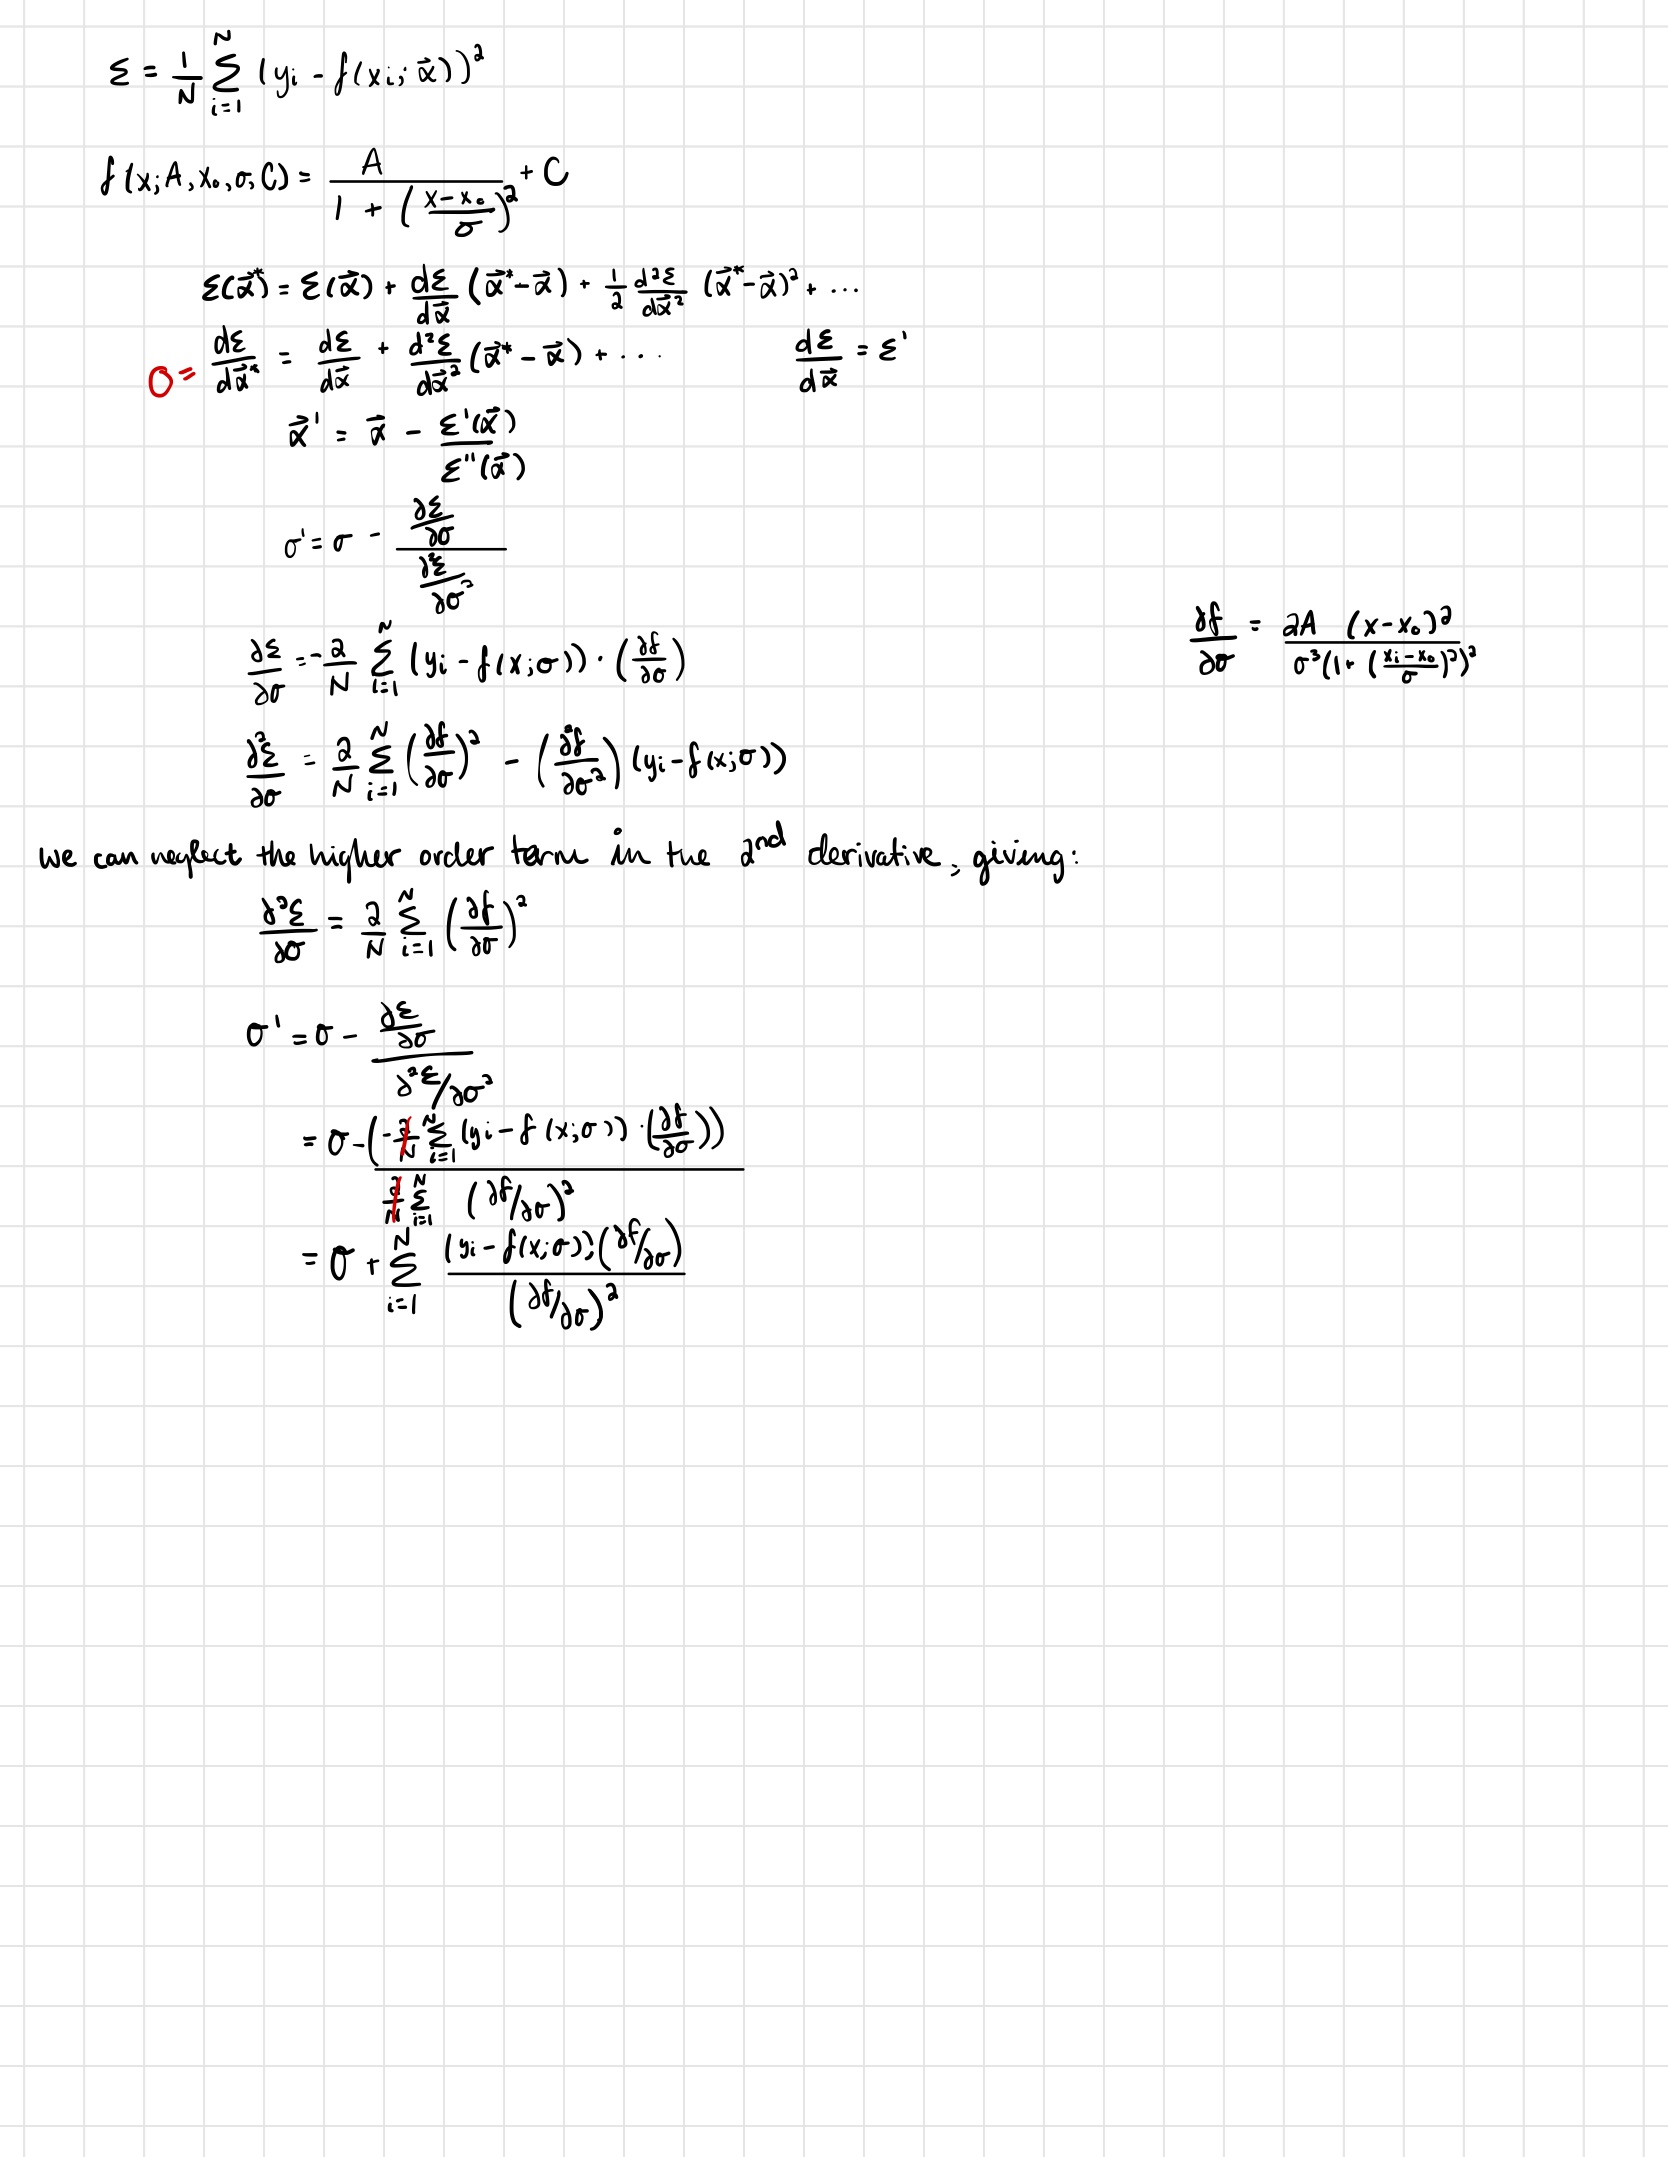

Question 1b

In [3]:
#function for the Gauss-Newton Method
def GaussNewton(x, y, A, sigma, x0, C):
    N = len(x)
    
    numerator = 0
    denominator = 0
    for i in range(N):
        
        #get the formula for f(x, alpha)
        f = A / (1+((x[i] - x0)/sigma)**2) + C
        r = y[i] - f #term inside the sum
        #derivative
        df = (2 * A * (x[i] - x0)**2) / (sigma**3 * (1 + ((x[i] - x0)/sigma)**2)**2)

        #calculate the sum
        numerator += r * (-df)
        denominator += df**2
    #plug the result into the update equation
    sigma_new = sigma - numerator/denominator
    return sigma_new


Question 1c

In [4]:
#larger function to run with the file
def GNS(filename):
    #read in the file and get the data
    data = np.loadtxt(filename, float)
    x = data[:, 0]
    y = data[:, 1]

    #initialize variables
    A = 5
    x0 = 4
    C = 1
    sigma = 0.1
    converge = 1e-6
    max_iters = 1000
    iter = 0

    
    while iter < max_iters:
        #update sigma using Gauss-Newton
        sigma_new = GaussNewton(x, y, A, sigma, x0, C)

        #check against convergence threshold
        if abs(sigma_new - sigma) < converge:
            sigma = sigma_new
            break
        #get new sigma value
        sigma = sigma_new
        #update number of iterations
        iter += 1
        
    return sigma, iter

sigma_n, iterations = GNS("Data_yi_vs_xi.txt")


print("\nThe final converged value is: ", sigma_n)
print("\nThe number of iterations is: ", iterations)


The final converged value is:  0.5219512601130349

The number of iterations is:  6


Question 1d

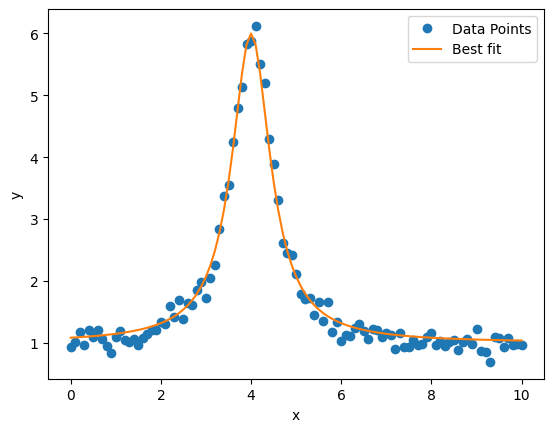

In [5]:
data = np.loadtxt("Data_yi_vs_xi.txt", float)
x2 = data[:, 0]
y2 = data[:, 1]

A = 5
x0 = 4
C = 1

#function for f(x, alpha)
def f(x2, A, x0, sigma, C):
    return A / (1+((x2-x0)/sigma)**2)+C

#plot the data
plt.plot(x2, y2, 'o', label="Data Points")
plt.plot(x2, f(x2, A, x0, sigma_n, C), label="Best fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

Question 1e

In [6]:
#function for the sum
def objective(sigma, x_data, y_data, A, x0, C):
    y_pred = f(x_data, A, x0, sigma, C)
    return np.sum((y_data - y_pred)**2)

#function to calculate the Golden Ratio
def Golden_Ratio(x, y, a = 0.01, b=1.0, tol=1e-6, max_iter=1000):
    phi = (1 + np.sqrt(5)) / 2
    resphi = 2-phi

    #calculate the sigma values
    c = a+resphi * (b-a)
    d = b - resphi * (b-a)

    #get the f for each sigma value
    fc = objective(c, x, y, A, x0, C)
    fd = objective(d, x, y, A, x0, C)

    #number of iterations
    iters = 0

    #check against convergence and program constraints
    while abs(b-a) > tol and iters < max_iter:
        #update the sigma values and continue searching for better fit
        #choose what value of sigma to move closer to
        if fc < fd:
            b = d
            d = c
            fd = fc
            c = a + resphi*(b-a)
            fc = objective(c, x, y, A, x0, C)

        else:
            a=c
            c=d
            fc = fd
            d = b - resphi * (b-a)
            fd = objective(d, x, y, A, x0, C)

        iters += 1
    
    sigma_opt = (a+b)/2

    return sigma_opt, iters

sigma_best, iters = Golden_Ratio(x2, y2)
print("The final converged value is: ", sigma_best)
print("\nThe number of iterations is: ", iters)

The final converged value is:  0.5219515113741199

The number of iterations is:  29


Question 1f

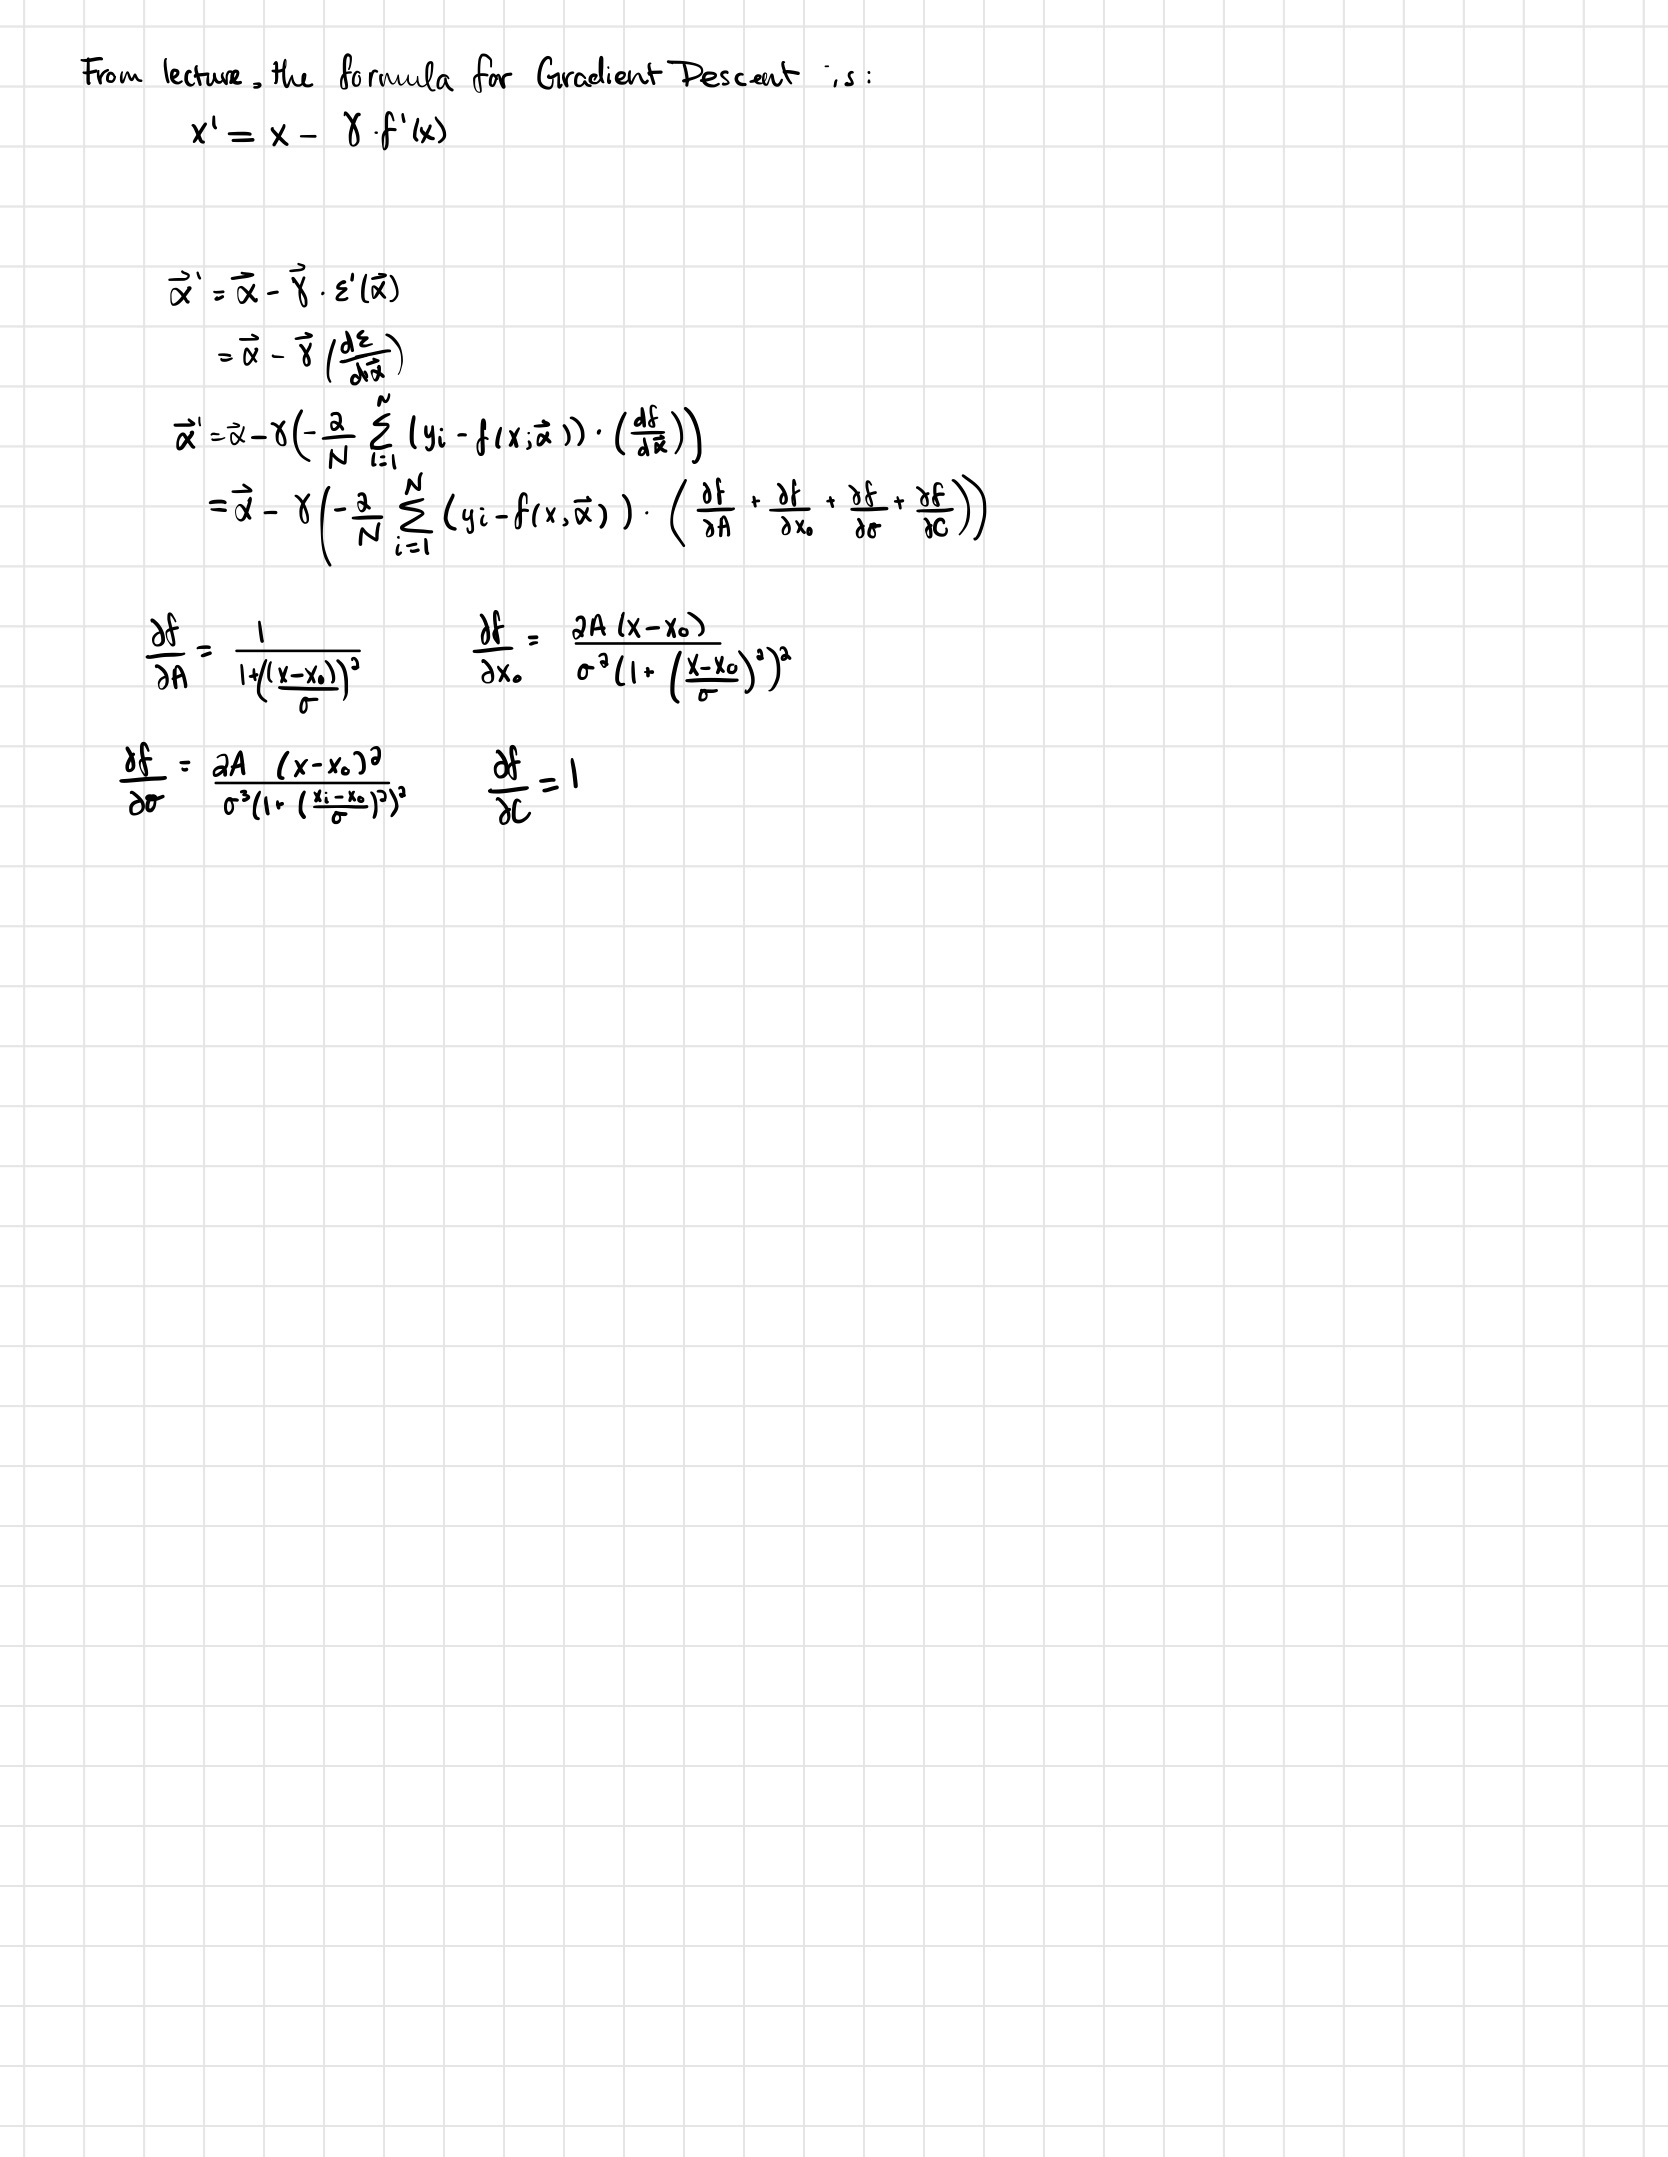

Question 1g

In [7]:
#function for Gradient descent method
def Grad_Descent(filename):
    #load in data
    data = np.loadtxt(filename, float)
    x = data[:, 0]
    y = data[:, 1]

    #initialize variables
    A = 2.0
    x0 = 2.0
    C = 2.0
    sigma = 2.0
    gamma = 0.002
    converge = 1e-6
    max_iters = 1000
    N = len(x)
    iters = 0

    while iters < max_iters:

        #initialize derivatives
        dA = 0
        dx0 = 0
        dsigma = 0
        dC = 0

        for i in range(N):
            #calculate the parts of the equations
            denom = 1 + ((x[i]-x0)/sigma)**2
            f = A/denom + C
            r = y[i] - f

            #derivative values
            dfdA = 1/denom
            dfdC = 1
            dfdx0 = (2*A*(x[i]-x0)) / (sigma**2 * denom**2)
            dfdsigma = (2*A*(x[i]-x0)**2) / (sigma**3 * denom**2)

            dA += -2 * r *dfdA
            dx0 += -2 * r * dfdx0
            dsigma += -2 * r * dfdsigma
            dC += -2 * r * dfdC

        #save the previous values for convergence comparisons
        A_old, x0_old, sigma_old, C_old = A, x0, sigma, C

        #update variables
        A -= gamma * dA
        x0 -= gamma * dx0
        sigma -= gamma * dsigma
        C -= gamma * dC

        #check convergences
        if (abs(A - A_old) < converge and
            abs(x0 - x0_old) < converge and
            abs(sigma - sigma_old) < converge and
            abs(C - C_old) < converge):
            break

        iters += 1
    return A, x0, sigma, C, iters

A, x0, sig, C, iters = Grad_Descent("Data_yi_vs_xi.txt")

print("The final converged value of A is: ", A)
print("\nThe final converged value of x0 is: ", x0)
print("\nThe final converged value of sigma is: ", sig)
print("\nThe final converged value of C is: ", C)
print("\nThe number of iterations is: ", iters)

The final converged value of A is:  5.15887238284453

The final converged value of x0 is:  4.0207283396315425

The final converged value of sigma is:  0.5329439664025353

The final converged value of C is:  0.9211466659122387

The number of iterations is:  656


Question 2a

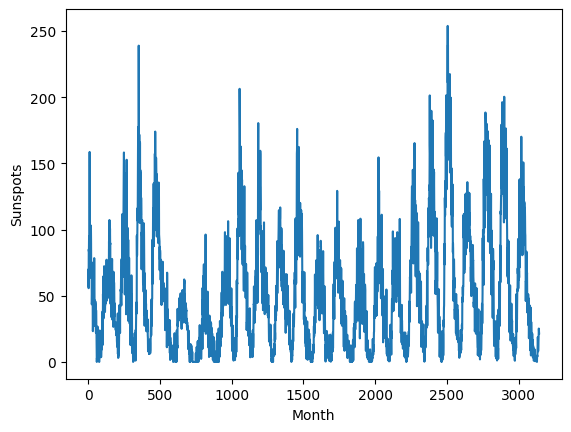

In [8]:
#read in data using pandas
data = pd.read_csv('sunspots.txt', sep='\t', header=None, names=["Time", "Sunspots"])

x = data["Time"]
y = data["Sunspots"]

#plot data
plt.plot(x, y)
plt.xlabel("Month")
plt.ylabel("Sunspots")
plt.show()

The monthly period is estimated to be 125

Question 2b

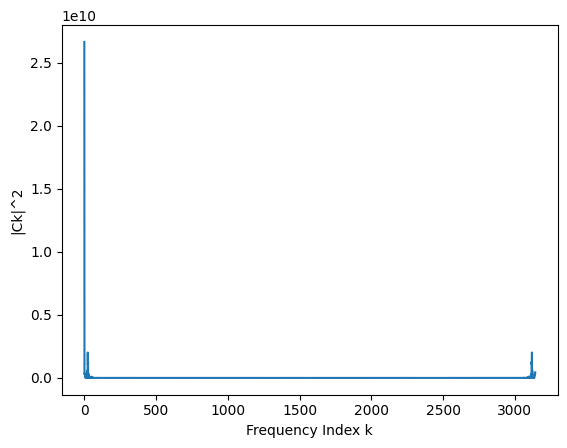

In [9]:
#Function for Discrete Fourier Transform
def DFT(x):
    #initialize array of input
    x = np.asarray(x, dtype=complex)
    N = len(x)
    #initialize array of coefficients
    y = np.zeros(N, dtype=complex)

    for i in range(N):
        for j in range(N):
            #use the equation from class to find the coefficients
            y[i] += x[j] * np.exp(-2j * np.pi * i * j / N)

    return y

#get the dft
dft = DFT(data["Sunspots"])

#get the power and plot
power = np.abs(dft)**2
plt.plot(power)
plt.xlabel("Frequency Index k")
plt.ylabel("|Ck|^2")
plt.show()

Question 2c

In [10]:
N = len(power)

#search for the non-zero peak
search_region = power[1:N//2]

k_peak = np.argmax(search_region) + 1
print("Peak occurs at k = ", k_peak)

#get the monthly period
period = N / k_peak

print("The monthly period is: ", period)

Peak occurs at k =  24
The monthly period is:  130.95833333333334


Question 3a

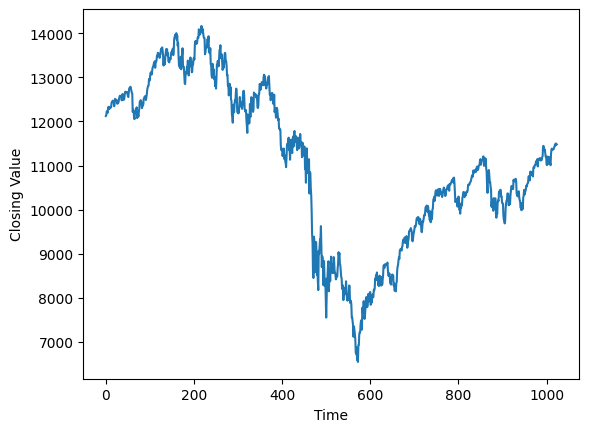

In [11]:
#import the data
dow = pd.read_csv('dow.txt', sep='\t', header=None, names=["Closing Value"])

clos = dow["Closing Value"]

#plot the data
plt.plot(clos)
plt.xlabel("Time")
plt.ylabel("Closing Value")
plt.show()

Question 3b

In [12]:
#use the function from 2 to calculate the DFT
coef = DFT(clos)
print(coef)


[11283903.94000001     +0.j           684127.73979081-955087.51914779j
  -419226.20512243 +92908.95615825j ...    74190.14983176+273812.2500396j
  -419226.20512166 -92908.95615827j   684127.73979081+955087.51914775j]


Question 3c

In [13]:
#set everything but the first 10% of coefficients to 0
N_c = len(coef)
print(N_c)

#find the index where the first 10% ends
percent10 = (int) (N * 0.1)

#set the other values to 0
for k in range(percent10+1,N_c):
    coef[k] = 0

print(coef)

1024
[11283903.94000001     +0.j           684127.73979081-955087.51914779j
  -419226.20512243 +92908.95615825j ...        0.             +0.j
        0.             +0.j                0.             +0.j        ]


Question 3d

c:\Users\baile\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\baile\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


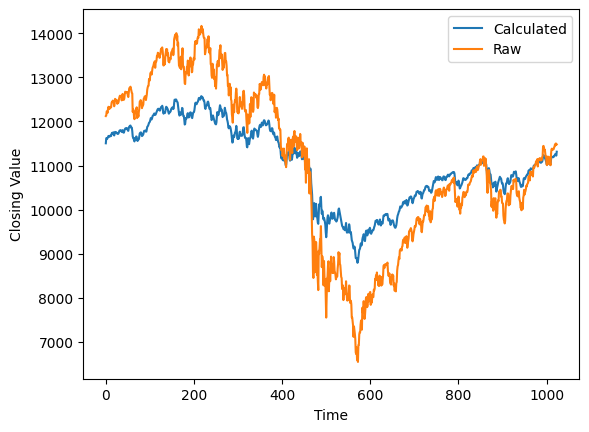

In [14]:
#Function for the inverse Fourier Transform
def IFT(x):
    #initialize arrays
    x = np.asarray(x, complex)
    N = len(x)
    y = np.zeros(N, complex)

    for i in range(N):
        for j in range(N):
            #use the equation from class
            y[i] += x[j] * np.exp(2j * np.pi * j * i / N)
        y[i] /= N

    return y

#get the result
inv_c = IFT(coef)

#plot the data compared to the original data
plt.plot(inv_c)
plt.plot(clos)
plt.ylabel("Closing Value")
plt.xlabel("Time")
plt.legend(['Calculated', 'Raw'], loc="upper right")

plt.show()

The overall trend of the curve softens a bit. The highs and lows are less sharp.

Question 3e

[11283903.94000001     +0.j           684127.73979081-955087.51914779j
  -419226.20512243 +92908.95615825j ...        0.             +0.j
        0.             +0.j                0.             +0.j        ]


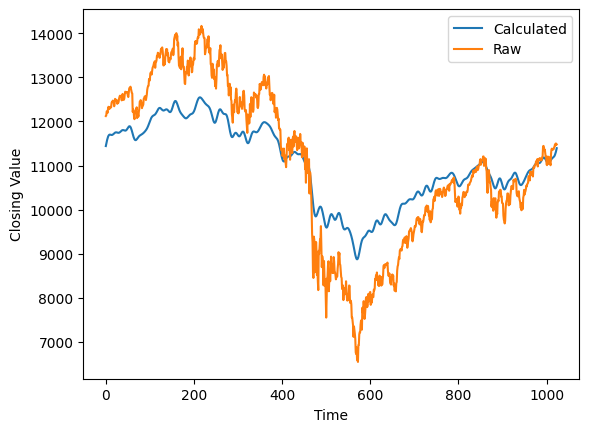

In [15]:
#set everything but the first 2% to 0
percent2 = (int) (N * 0.02)

for k in range(percent2+1,N_c):
    coef[k] = 0

print(coef)

#get the  IFT
inv_c2 = IFT(coef)

#plot the data
plt.plot(inv_c2)
plt.plot(clos)
plt.ylabel("Closing Value")
plt.xlabel("Time")
plt.legend(['Calculated', 'Raw'], loc="upper right")

plt.show()


Here even less peaks appear which makes the data smoother

In [1]:
result = 5 + "10"

print(result)

TypeError: unsupported operand type(s) for +: 'int' and 'str'